# 第015单元 局部近似与优化几何

## 目标
从固定二维正定二次函数推导稳定步长，再用代码核验边界、尺度变换与局部模型失败。先修011、013；所有参数是行向量 `(1,2)`，Hessian 是 `(2,2)`。

已执行的默认结果：曲率1和25，所有初值稳定区间严格为 `0 < eta < 0.08`。边界步长0.08的损失趋25而非0。这只是合成函数的机制证明，不是神经网络全局收敛结论。

## 设置
从本单元目录打开并重新启动内核，按顺序运行全部单元。只需Python与NumPy；图形为预先生成的原创PNG。没有网络、GPU或随机采样。

核心公式与完整命令在 lecture.md、lab.md；源码 experiment.py 可以单独运行，test_experiment.py 包含独立Fraction oracle。

In [1]:
from pathlib import Path
import json
import numpy as np
from IPython.display import display, Image
import experiment as ex
root = Path.cwd()
assert (root / 'data/config.json').is_file(), '请从本单元目录运行'
config = json.loads((root / 'data/config.json').read_text(encoding='utf-8'))
H = np.asarray(config['hessian'], dtype=float)
p = ex.row(config['initial_point'])
print('参数shape:', p.shape, 'Hessian shape:', H.shape)
print('NumPy:', np.__version__)

参数shape: (1, 2) Hessian shape: (2, 2)
NumPy: 2.3.5


## 步骤一 核对初值与主方向
在读取输出前手算 q(2,0)=26、g=(26,-24)。eigh的特征向量按列返回，符号不唯一。请核验重构，而不是逐元素比较符号。

In [2]:
print('初始损失:', ex.quadratic(p,H))
print('初始梯度:', ex.gradient(p,H))
values, vectors = ex.spectrum(H)
print('特征值:', values)
print('正交性最大误差:', np.max(np.abs(vectors.T @ vectors - np.eye(2))))
print('重构最大误差:', np.max(np.abs(vectors @ np.diag(values) @ vectors.T - H)))
assert np.allclose(values,[1,25])
assert np.allclose(vectors @ np.diag(values) @ vectors.T,H)

初始损失: 26.0
初始梯度: [[ 26. -24.]]
特征值: [ 1. 25.]
正交性最大误差: 2.220446049250313e-16
重构最大误差: 3.552713678800501e-15


### 步骤二 同一梯度 不同步长
每一行都是独立从(2,0)开始的运行。首步最好与60步最好是两个问题。

eta=0.02: first=(1.48,0.48), loss1=7.2104, loss60=0.0885378727
eta=0.04: first=(0.96,0.96), loss1=0.9216, loss60=0.00745672222
eta=0.075: first=(0.05,1.8), loss1=19.99625, loss60=8.92456728e-05
eta=0.08: first=(-0.08,1.92), loss1=25.8464, loss60=25.0000451
eta=0.09: first=(-0.34,2.16), loss1=39.8906, loss60=1.06448996e+13


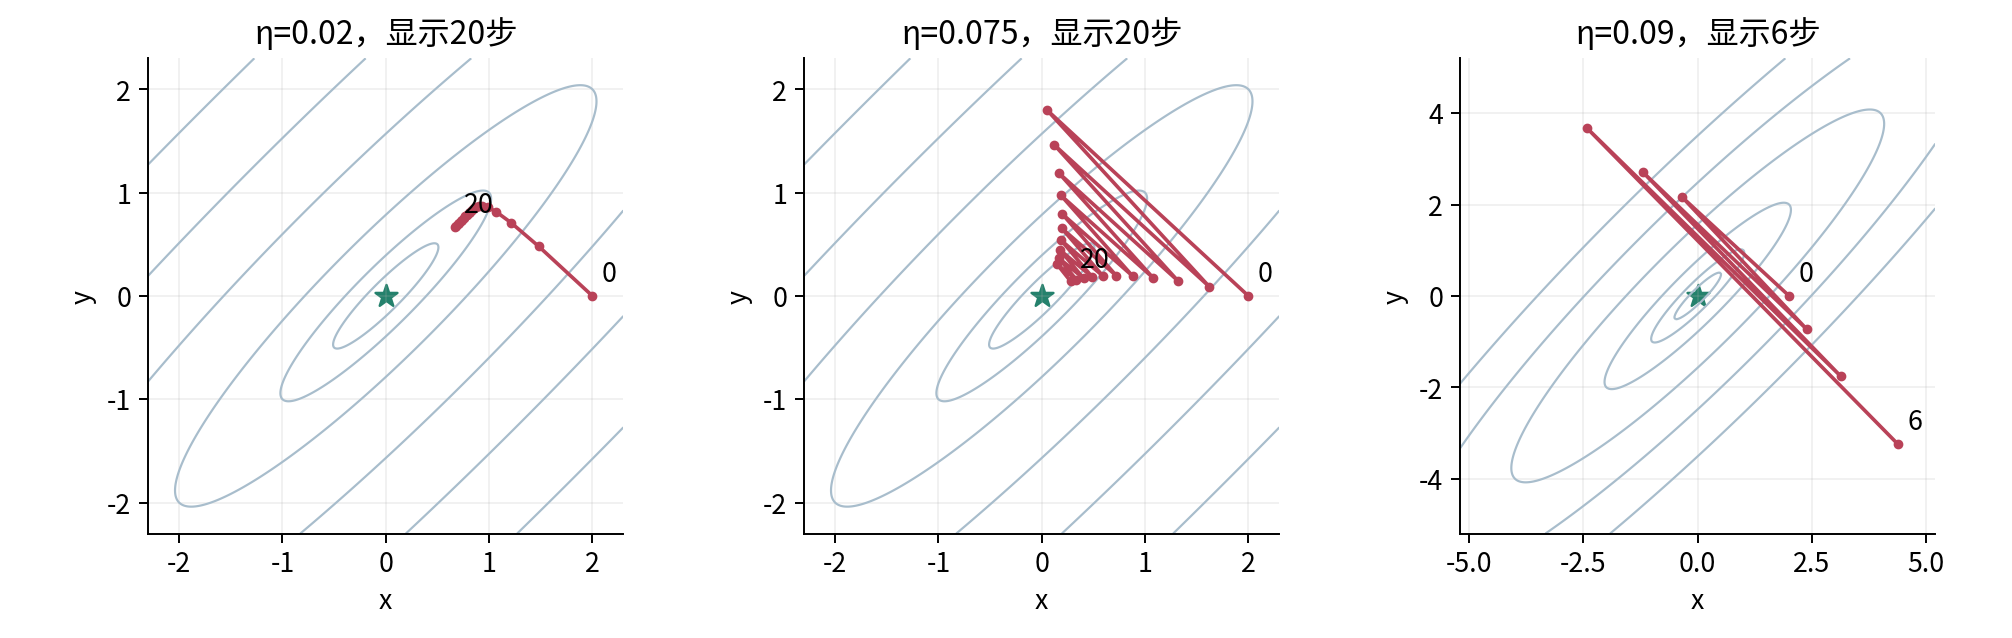

In [3]:
for eta in config['step_sizes']:
    rows = ex.trajectory(p,H,eta,config['iterations'])
    print(f"eta={eta:g}: first=({rows[1]['x']:.5g},{rows[1]['y']:.5g}), "
          f"loss1={rows[1]['loss']:.8g}, loss60={rows[-1]['loss']:.9g}")
display(Image(filename=str(root/'figures/07_trajectories.png'),width=900))

### 步骤三 从乘数推出范围
z的每个坐标独立乘 `1-eta*lambda`。绝对值小于1才衰减；负乘数表示符号翻转。数学推导给严格上界，图和有限次运行不负责证明无限序列收敛。

In [4]:
print(ex.spd_bounds(H))
for eta in [.02,.04,.075,.08,.09]:
    factors = 1-eta*values
    print(eta, '方向乘数', factors)
print('最坏方向最优固定步长:', 2/(1+25))
print('最坏方向收缩因子:', (25-1)/(25+1))

{'minimum_curvature': 1.0, 'maximum_curvature': 25.0, 'eta_strict_upper': 0.08, 'condition_number': 25.0}
0.02 方向乘数 [0.98 0.5 ]
0.04 方向乘数 [0.96 0.  ]
0.075 方向乘数 [ 0.925 -0.875]
0.08 方向乘数 [ 0.92 -1.  ]
0.09 方向乘数 [ 0.91 -1.25]
最坏方向最优固定步长: 0.07692307692307693
最坏方向收缩因子: 0.9230769230769231


### 步骤四 单调损失也可能停在错误平台
边界 eta=0.08 有精确公式 `loss_k=25+0.92**(2*k)`。同时查看主方向坐标，陡峭方向始终在正负sqrt(2)之间交替。

In [5]:
Q = np.array([[1.,1.],[1.,-1.]])/np.sqrt(2)
boundary = ex.trajectory(p,H,.08,60)
for k in [0,1,2,20,60]:
    r = boundary[k]
    z = np.array([[r['x'],r['y']]]) @ Q
    expected = 25+.92**(2*k)
    print(k, 'z=',np.round(z,6), 'loss=',round(r['loss'],8))
    assert np.isclose(r['loss'],expected)
assert boundary[-1]['loss'] > 25

0 z= [[1.414214 1.414214]] loss= 26.0
1 z= [[ 1.301076 -1.414214]] loss= 25.8464
2 z= [[1.19699  1.414214]] loss= 25.71639296
20 z= [[0.266853 1.414214]] loss= 25.03560517
60 z= [[0.009501 1.414214]] loss= 25.00004514


### 步骤五 先下降后增长 与特殊初值
0.08005的首步满足当前方向下降区间，但长期有不稳定分量；0.09从(1,1)开始则没有该分量。两者都不违反统一稳定条件的量词。

In [6]:
late = ex.trajectory(p,H,.08005,500)
special = ex.trajectory([[1,1]],H,.09,30)
print('0.08005的初值 首步 第500步损失:', late[0]['loss'],late[1]['loss'],late[-1]['loss'])
print('0.09在特殊初值(1,1)的第30步损失:',special[-1]['loss'])
assert late[1]['loss'] < late[0]['loss'] < late[-1]['loss']
assert special[-1]['loss'] < special[0]['loss']

0.08005的初值 首步 第500步损失: 26.0 25.908847064999986 87.19048650937755
0.09在特殊初值(1,1)的第30步损失: 0.003487253664116352


### 步骤六 检查非二次函数的余项
F=x^4+y^2/2，p=(1,1)，delta=(h,2h)。独立展开给一阶误差8h²+4h³+h⁴、二阶误差4h³+h⁴。

In [7]:
base = np.array([[1.,1.]])
for h in config['taylor_steps']:
    delta = np.array([[h,2*h]])
    first,second = ex.local_models(ex.polynomial(base),ex.polynomial_gradient(base),ex.polynomial_hessian(base),delta)
    actual = ex.polynomial(base+delta)
    print(h,'实际 一阶 二阶:',round(actual,8),round(first,8),round(second,8),
          '误差:',round(actual-first,10),round(actual-second,10))
    assert np.isclose(actual-first,8*h*h+4*h**3+h**4)
    assert np.isclose(actual-second,4*h**3+h**4)

0.2 实际 一阶 二阶: 3.0536 2.7 3.02 误差: 0.3536 0.0336
0.1 实际 一阶 二阶: 2.1841 2.1 2.18 误差: 0.0841 0.0041
0.05 实际 一阶 二阶: 1.82050625 1.8 1.82 误差: 0.02050625 0.00050625
0.025 实际 一阶 二阶: 1.65506289 1.65 1.655 误差: 0.0050628906 6.28906e-05


### 步骤七 用梯度差分核对Hessian
数值Hessian不是直接抄解析矩阵。对于F，有限h的H11应为12+4h²；误差既可能来自截断，也可能来自浮点范围或相消。

In [8]:
for h in [.1,.01,.001]:
    estimate = ex.finite_difference_hessian(ex.polynomial_gradient,base,h)
    print('h=',h,'H11=',estimate[0,0],'预期=',12+4*h*h)
    assert np.allclose(estimate,np.diag([12+4*h*h,1]),atol=1e-8)
quadratic_est = ex.finite_difference_hessian(lambda t: ex.gradient(t,H),p,.001)
assert np.allclose(quadratic_est,H,atol=1e-8)

h= 0.1 H11= 12.040000000000006 预期= 12.04
h= 0.01 H11= 12.000400000000022 预期= 12.0004
h= 0.001 H11= 12.000003999999453 预期= 12.000004


### 步骤八 缩放后的算法映回原坐标
w=theta Q diag(1,5)，新目标为w的平方长度一半。在w中eta=1一步到0，映回theta也为0。请从分量链式法则解释这与直接在theta中使用eta=1为何不同。

w初值: [[1.41421356 7.07106781]] w梯度: [[1.41421356 7.07106781]]
映回theta后的新点: [[-7.53644380e-16 -5.02429587e-16]]


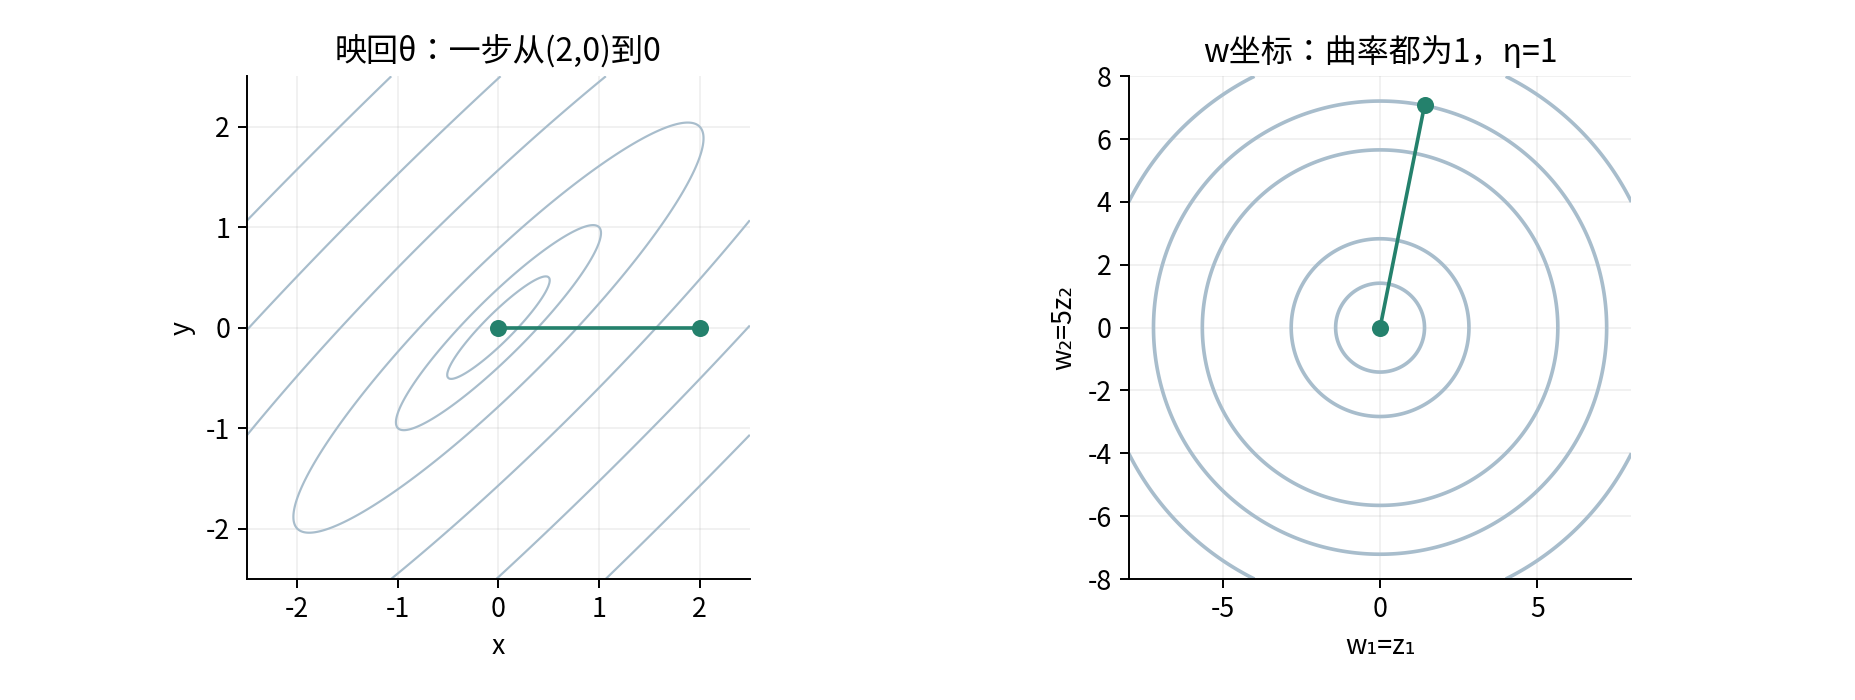

In [9]:
S=np.diag([1.,5.]); Si=np.diag([1.,.2])
w=p@Q@S
gw=ex.gradient(p,H)@Q@Si
new_theta=(w-gw)@Si@Q.T
print('w初值:',w,'w梯度:',gw)
print('映回theta后的新点:',new_theta)
assert np.allclose(gw,w)
assert np.allclose(new_theta,0,atol=1e-12)
display(Image(filename=str(root/'figures/09_scaling.png'),width=800))

### 步骤九 单点Hessian的失败
R=x+x²/2+10x⁴+y²/2。在原点g=(1,0)、H=I，eta=1的二阶模型预测-0.5；实际值为9.5。必须控制整条线段的曲率。

In [10]:
old = ex.steepening([[0,0]])
new = ex.steepening([[-1,0]])
print('旧值:',old,'新值:',new,'原点二阶预测:',-.5)
print('更新线段最大曲率:',121,'相应充分上界:',2/121)
assert old == 0 and new == 9.5

旧值: 0.0 新值: 9.5 原点二阶预测: -0.5
更新线段最大曲率: 121 相应充分上界: 0.01652892561983471


## 检查 输入失效必须可见
下面故意给错误输入并捕获预期异常。数值有限检查并非任意精度：舍入与下溢仍可能发生，不能因显示0就宣布数学上严格为0。

In [11]:
bad_calls = [
    ('错误shape',lambda:ex.gradient([2,0],H)),
    ('嵌套布尔叶子',lambda:ex.gradient([[np.array(True),0]],H)),
    ('不对称H',lambda:ex.gradient(p,[[13,-12],[-11,13]])),
    ('更新溢出',lambda:ex.step(p,H,1e308)),
    ('不可分辨差分步长',lambda:ex.finite_difference_hessian(ex.polynomial_gradient,base,1e-20)),
    ('差分分母溢出',lambda:ex.finite_difference_hessian(ex.polynomial_gradient,base,1e308))]
for label,call in bad_calls:
    try:
        call()
    except (TypeError,ValueError,ArithmeticError) as err:
        print(label,type(err).__name__)
    else:
        raise AssertionError(label+' 本应失败')

错误shape ValueError
嵌套布尔叶子 TypeError
不对称H ValueError
更新溢出 ArithmeticError
不可分辨差分步长 ArithmeticError
差分分母溢出 ArithmeticError


## 保存可复核的运行结果
Notebook输出另存到notebook_outputs，不覆盖随课程提供的脚本示例。两条入口调用同一实现，输出一致不是独立科学核验；独立性由标量Fraction oracle补充。

In [12]:
result = ex.run(root/'data/config.json',root/'notebook_outputs')
for name in ['results.json','taylor.csv','trajectories.csv','environment.json']:
    same = (root/'outputs'/name).read_bytes() == (root/'notebook_outputs'/name).read_bytes()
    print(name,'与脚本输出一致:',same)
    assert same
print('已保存',len(result['runs']),'条步长汇总')

results.json 与脚本输出一致: True
taylor.csv 与脚本输出一致: True
trajectories.csv 与脚本输出一致: True
environment.json 与脚本输出一致: True
已保存 5 条步长汇总


## 独立测试与下一步
运行11组独立测试。修改配置前请复制为新文件，输出使用新目录；一次失败后仍存在的旧输出不能当作新结果。

完成后用自己的话回答：为什么0.08必须是严格上界？为何平台25不是最优？哪种信息来自函数的全局结构，哪种只来自局部导数？

In [13]:
import unittest
import test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
report=unittest.TextTestRunner(verbosity=1).run(suite)
assert report.wasSuccessful()
print('独立测试组数:',report.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 11 tests in 0.955s

OK


独立测试组数: 11
